In [4]:
import sys
sys.path.append("/Users/emilieyu/endotehelial-masboss")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from src.utils import load_abm_sim_cfg, load_csv_to_df, save_figure
from src.paths import ABM_SIM_FIG_DIR, LUT_DIR, ABM_SIM_RES_DIR, REPORT_FIG_DIR, ABM_RESULTS_ARCH

from src.visualisation.line_plotter import plot_metric_timeseries
from src.visualisation.style import PERTURBATION_COLOURS

from src.abm.experiments.experiment_runner import ExperimentRunner
from src.abm.plotting.cell_plotter import plot_cell, plot_cells_grid
from src.abm.plotting.timeseries import *

## All Cells Plot

In [5]:
sim_cfg = load_abm_sim_cfg()
runner = ExperimentRunner(sim_cfg, LUT_DIR)
results = runner.run_all()


>>> DEBUG: Successfully loaded recruitment parameter sweep data.
>>> DEBUG: Successfully built interpolators
LUT ready | rest: RhoA=0.398 RhoC=0.403
>>> INFO: Running perturbation: WT for 6000 steps.
 WT ar=1.652 | rho_balance=0.011 | rhoa=0.582 | rhoc=0.571 | t=6.8s
>>> INFO: Running perturbation: DSP_KO for 6000 steps.
 DSP_KO ar=2.131 | rho_balance=-0.484 | rhoa=0.232 | rhoc=0.716 | t=7.4s
>>> INFO: Running perturbation: TJP1_KO for 6000 steps.
 TJP1_KO ar=1.357 | rho_balance=0.516 | rhoa=0.743 | rhoc=0.227 | t=7.5s
>>> INFO: Running perturbation: JCAD_KO for 6000 steps.
 JCAD_KO ar=1.662 | rho_balance=0.021 | rhoa=0.502 | rhoc=0.481 | t=5.6s
>>> INFO: Running perturbation: DSP_JCAD_DKO for 6000 steps.
 DSP_JCAD_DKO ar=1.968 | rho_balance=-0.298 | rhoa=0.299 | rhoc=0.597 | t=6.1s
>>> INFO: Running perturbation: TJP1_JCAD_DKO for 6000 steps.
 TJP1_JCAD_DKO ar=1.477 | rho_balance=0.323 | rhoa=0.610 | rhoc=0.287 | t=7.2s


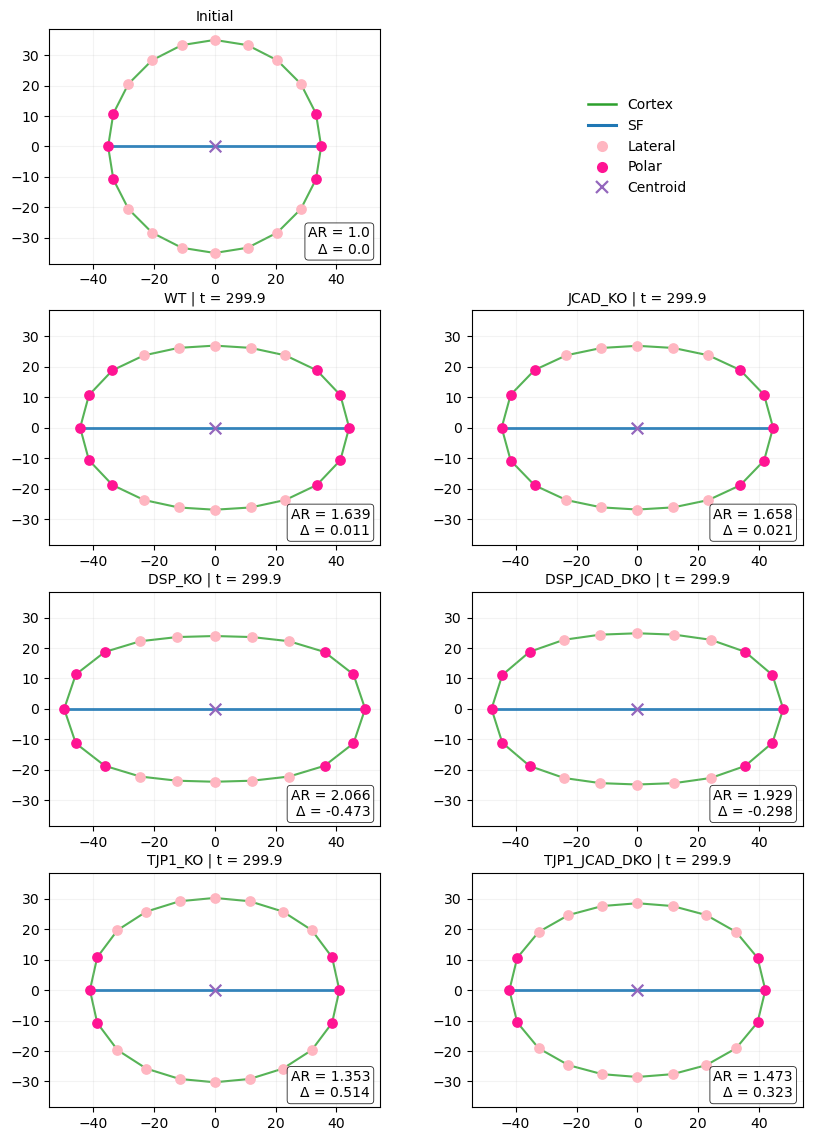

In [3]:
plot_cells_grid(results)

## Timeseries Plots

In [2]:
cell_ts_df = load_csv_to_df(in_dir=ABM_SIM_RES_DIR, file_name="abm_cell_timeseries")

>>> INFO: Loaded abm_cell_timeseries.csv from /Users/emilieyu/endotehelial-masboss/results/abm/sim


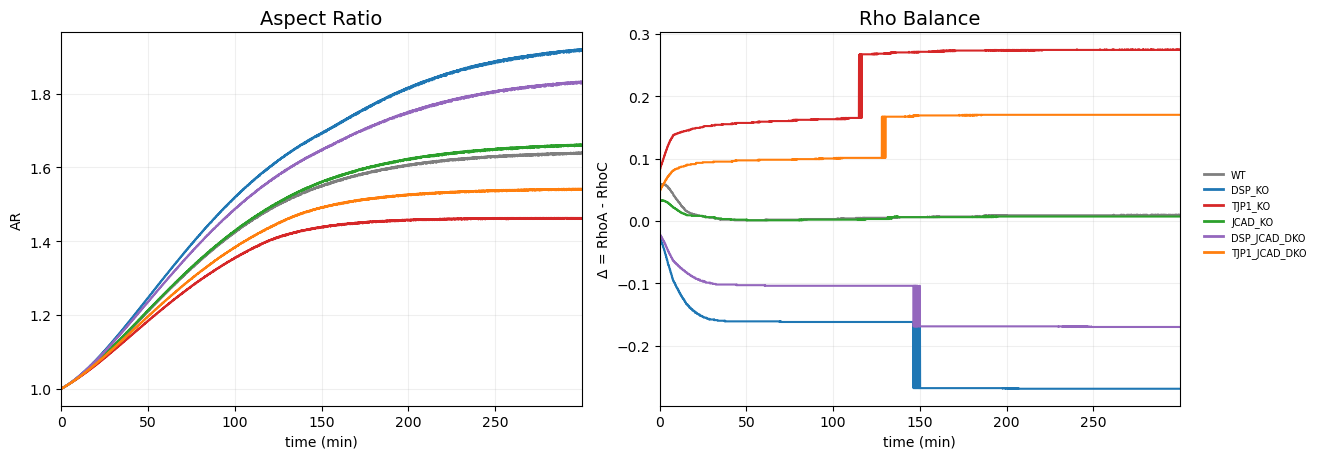

In [5]:
plot_ar_and_rho_timeseries(cell_ts_df, REPORT_FIG_DIR)

## Manual Report Plot

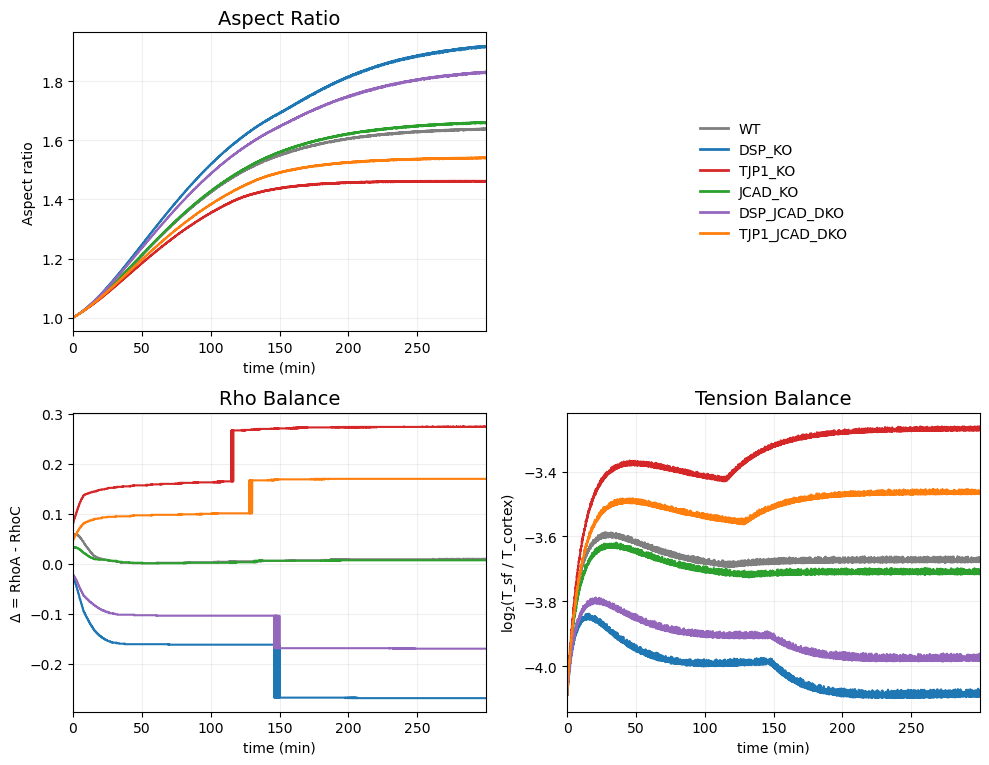

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
ax_ar, ax_leg = axes[0]
ax_rho, ax_tension = axes[1]

plot_metric_timeseries(
    cell_ts_df,
    y_col="ar",
    y_label="Aspect ratio",
    ax=ax_ar,
    order=None,
    colour_map=PERTURBATION_COLOURS,
)

plot_metric_timeseries(
    cell_ts_df,
    y_col="rho_balance",
    y_label="Δ = RhoA - RhoC",
    ax=ax_rho,
    order=None,
    colour_map=PERTURBATION_COLOURS,
)

plot_metric_timeseries(
    cell_ts_df,
    y_col="tension_balance",
    y_label=r"log$_2$(T_sf / T_cortex)",
    ax=ax_tension,
    order=None,
    colour_map=PERTURBATION_COLOURS,
)

# remove legends
for ax in [ax_ar, ax_rho, ax_tension]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

# panel titles
ax_ar.set_title("Aspect Ratio", fontsize=14)
ax_rho.set_title("Rho Balance", fontsize=14)
ax_tension.set_title("Tension Balance", fontsize=14)

# shared legend in empty axis
labels = cell_ts_df["perturbation"].drop_duplicates().tolist()
handles = [
    plt.Line2D([0], [0], color=PERTURBATION_COLOURS.get(p, "black"), lw=2)
    for p in labels
]

ax_leg.legend(
    handles,
    labels,
    loc="center",
    frameon=False,
    fontsize=10,
)

ax_leg.axis("off")

#fig.suptitle("ABM key dynamics", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()